# 03 — Factorial Designs: 2^k Full Factorial
**References:** Box, Hunter & Hunter (2005) Ch. 4-5 · Montgomery (2017) Ch. 6

## Narrative thread
```
Why factorial beats one-at-a-time -> 2^2 factorial -> Main effects & interactions -> 2^k -> Effect hierarchy
```

## Why factorial designs?

**One-at-a-time (OFAT)** approach: vary one factor, hold all others fixed.
Problem: misses **interactions** — when the effect of A depends on the level of B.

**Factorial design:** vary all factors simultaneously. More efficient AND discovers interactions.

Example: if A has a positive effect at B=low but no effect at B=high, OFAT (at B=low) overestimates A's average effect, and at B=high misses it entirely. The factorial design estimates both.

## The 2^2 full factorial

Two factors (A, B), each at two levels (−1 = low, +1 = high): $2^2 = 4$ runs.

| Run | A | B | AB | y |
|---|---|---|---|---|
| 1 | − | − | + | $y_1$ |
| 2 | + | − | − | $y_2$ |
| 3 | − | + | − | $y_3$ |
| 4 | + | + | + | $y_4$ |

**Main effect of A:** $[A] = \frac{1}{2}[(y_2 - y_1) + (y_4 - y_3)] = \frac{(-y_1+y_2-y_3+y_4)}{2}$

Change in response when A goes from − to +, averaged over levels of B.

**Interaction AB:** $[AB] = \frac{1}{2}[(y_4 - y_3) - (y_2 - y_1)]$

How much the effect of A changes when B goes from − to +.

## Effect hierarchy principle (Box & Meyer, 1986)

1. Main effects are usually larger than 2-factor interactions (2FI)
2. 2FIs are usually larger than 3-factor interactions (3FI)
3. Higher-order interactions are usually negligible

This principle justifies **fractional factorial** designs (notebook 04) — we can
sacrifice information on high-order interactions to estimate main effects and 2FIs
with far fewer runs.

## 2^k designs

| $k$ factors | Runs (no replication) | Parameters (with all interactions) |
|---|---|---|
| 2 | 4 | 4 ($\mu$, A, B, AB) |
| 3 | 8 | 8 |
| 4 | 16 | 16 |
| 5 | 32 | 32 |
| 7 | 128 | 128 |

With $k=5$ or more, most runs are "wasted" estimating negligible high-order interactions.
This motivates fractional factorial designs.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from itertools import product

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

2^2 Factorial: Conversion rate experiment
  True effects:      A=0.040  B=0.060  AB=0.030
  Estimated effects: A=0.0125  B=0.0375  AB=0.0175


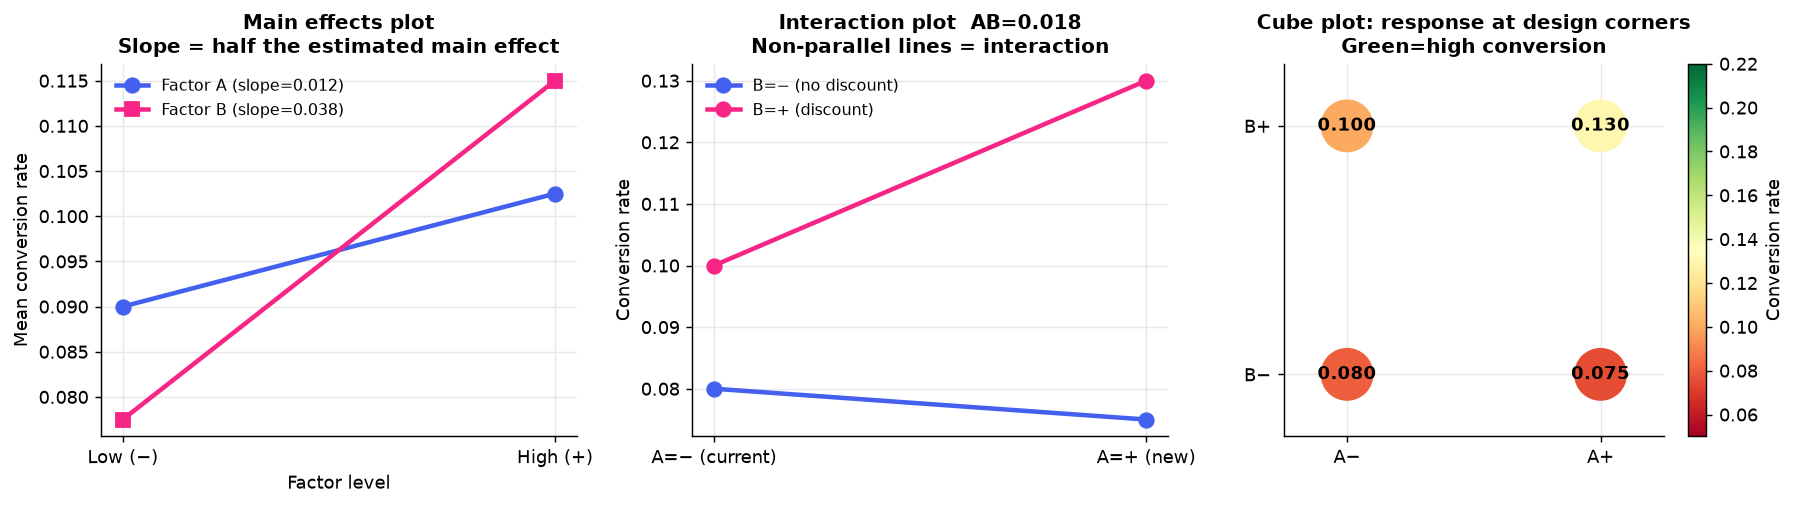

In [2]:
# ── 2^2 factorial: main effects and interaction ───────────────────────────
# Context: e-commerce experiment
# Factor A: page layout (-1=current, +1=new)
# Factor B: price discount (-1=none, +1=10% off)
# Response: conversion rate

np.random.seed(5)
n_per_cell = 200   # units per cell

# True effects (we'll verify we recover them)
mu_true  = 0.10    # baseline conversion
A_true   = 0.04    # layout effect
B_true   = 0.06    # discount effect
AB_true  = 0.03    # INTERACTION: discount helps more with new layout

design_22 = np.array([[-1,-1],[+1,-1],[-1,+1],[+1,+1]], dtype=float)
cells = {'(A-,B-)': (0,0), '(A+,B-)': (1,0), '(A-,B+)': (0,1), '(A+,B+)': (1,1)}

results_22 = {}
for i, (a,b) in enumerate(design_22):
    p_true = mu_true + A_true*(a/2) + B_true*(b/2) + AB_true*(a*b/4)
    p_true = np.clip(p_true, 0.01, 0.99)
    conversions = np.random.binomial(1, p_true, n_per_cell)
    results_22[(a,b)] = {'p_hat': conversions.mean(), 'n': n_per_cell, 'p_true': p_true}

y = np.array([results_22[(a,b)]['p_hat'] for a,b in design_22])

# Estimate effects using contrast vectors
effect_A  = (-y[0] + y[1] - y[2] + y[3]) / 2
effect_B  = (-y[0] - y[1] + y[2] + y[3]) / 2
effect_AB = ( y[0] - y[1] - y[2] + y[3]) / 2

print('2^2 Factorial: Conversion rate experiment')
print(f'  True effects:      A={A_true:.3f}  B={B_true:.3f}  AB={AB_true:.3f}')
print(f'  Estimated effects: A={effect_A:.4f}  B={effect_B:.4f}  AB={effect_AB:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Main effects plot
ax = axes[0]
a_levels = [-1, 1]
mean_A = [np.mean([results_22[(-1,-1)]['p_hat'], results_22[(-1,+1)]['p_hat']]),
          np.mean([results_22[(+1,-1)]['p_hat'], results_22[(+1,+1)]['p_hat']])]
mean_B = [np.mean([results_22[(-1,-1)]['p_hat'], results_22[(+1,-1)]['p_hat']]),
          np.mean([results_22[(-1,+1)]['p_hat'], results_22[(+1,+1)]['p_hat']])]
ax.plot([-1,1], mean_A, 'o-', color='#4361ee', lw=2.5, ms=8, label=f'Factor A (slope={effect_A:.3f})')
ax.plot([-1,1], mean_B, 's-', color='#f72585', lw=2.5, ms=8, label=f'Factor B (slope={effect_B:.3f})')
ax.set_xticks([-1,1]); ax.set_xticklabels(['Low (−)', 'High (+)'])
ax.set_xlabel('Factor level'); ax.set_ylabel('Mean conversion rate')
ax.set_title('Main effects plot\nSlope = half the estimated main effect')
ax.legend(fontsize=9)

# Interaction plot
ax2 = axes[1]
for b_val, color, label in [(-1, '#4361ee', 'B=− (no discount)'), (+1, '#f72585', 'B=+ (discount)')]:
    conv_a_lo = results_22[(-1, b_val)]['p_hat']
    conv_a_hi = results_22[(+1, b_val)]['p_hat']
    ax2.plot([-1,1], [conv_a_lo, conv_a_hi], 'o-', color=color, lw=2.5, ms=8, label=label)
ax2.set_xticks([-1,1]); ax2.set_xticklabels(['A=− (current)', 'A=+ (new)'])
ax2.set_ylabel('Conversion rate')
ax2.set_title(f'Interaction plot  AB={effect_AB:.3f}\nNon-parallel lines = interaction')
ax2.legend(fontsize=9)

# Cube plot (response at corners of 2^2)
ax3 = axes[2]
corners = design_22
y_corner = np.array([results_22[(a,b)]['p_hat'] for a,b in corners])
sc = ax3.scatter(corners[:,0], corners[:,1], s=800, c=y_corner, cmap='RdYlGn',
                  vmin=0.05, vmax=0.22, zorder=3)
for (a,b), yv in zip(corners, y_corner):
    ax3.text(a, b, f'{yv:.3f}', ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(sc, ax=ax3, label='Conversion rate')
ax3.set_xticks([-1,1]); ax3.set_xticklabels(['A−','A+'])
ax3.set_yticks([-1,1]); ax3.set_yticklabels(['B−','B+'])
ax3.set_xlim(-1.5, 1.5); ax3.set_ylim(-1.5, 1.5)
ax3.set_title('Cube plot: response at design corners\nGreen=high conversion')

plt.tight_layout()
plt.show()

## 2^3 factorial and effect hierarchy

With 3 factors (A, B, C), the full 2^3 design has 8 runs and estimates:
- 3 main effects: A, B, C
- 3 two-factor interactions: AB, AC, BC
- 1 three-factor interaction: ABC
- 1 overall mean: $\mu$

**Daniel's half-normal plot (1959):** plot absolute effects against their normal scores.
Effects that lie off the line are active (significant); effects on the line are noise.
This provides informal significance testing **without replication**.

2^3 Factorial effects:
     A: estimated=+8.563  true=+8.0
    AB: estimated=+4.354  true=+4.0
    AC: estimated=+2.472  true=+0.2
     C: estimated=-2.132  true=-0.3
     B: estimated=-1.747  true=+0.5
   ABC: estimated=+0.673  true=+0.1
    BC: estimated=+0.315  true=-0.4


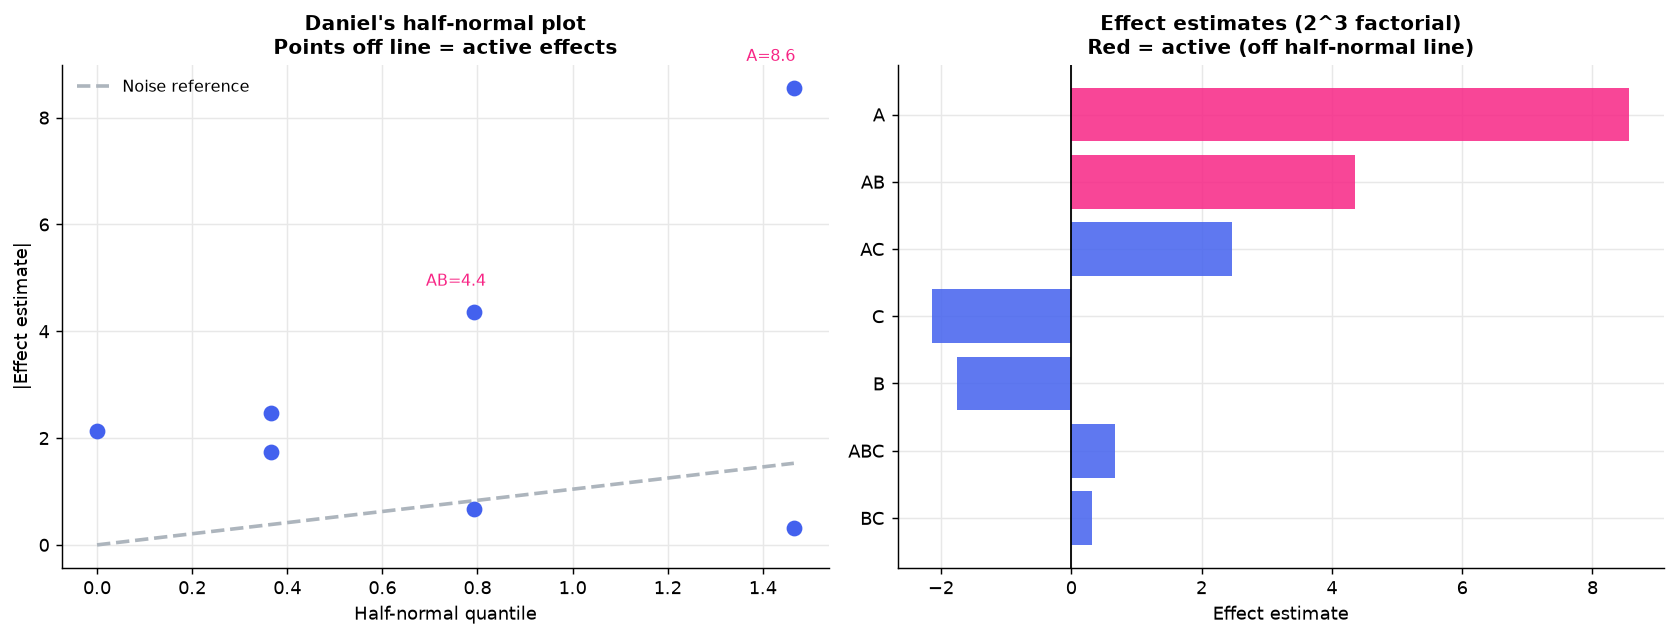

In [3]:
# ── 2^3 factorial: half-normal plot and analysis ─────────────────────────
from itertools import combinations

np.random.seed(11)
k3 = 3
# Full 2^3 design matrix (standard order)
design_23 = np.array(list(product([-1,1], repeat=3)), dtype=float)
factor_names = ['A', 'B', 'C']

# True effects: A and AB active, others noise
true_effects = {'A': 8.0, 'B': 0.5, 'C': -0.3,
                'AB': 4.0, 'AC': 0.2, 'BC': -0.4, 'ABC': 0.1}

def compute_y(d):
    A, B, C = d
    return (20 + true_effects['A']*(A/2) + true_effects['B']*(B/2) + true_effects['C']*(C/2)
            + true_effects['AB']*(A*B/4) + true_effects['AC']*(A*C/4)
            + true_effects['BC']*(B*C/4) + true_effects['ABC']*(A*B*C/8)
            + np.random.normal(0, 2))

y_23 = np.array([compute_y(row) for row in design_23])

# Compute all contrasts
contrasts = {}
col = {n: design_23[:,i] for i, n in enumerate(factor_names)}
col['AB'] = col['A']*col['B']
col['AC'] = col['A']*col['C']
col['BC'] = col['B']*col['C']
col['ABC'] = col['A']*col['B']*col['C']

n_runs = len(design_23)
for name, c in col.items():
    contrasts[name] = (c @ y_23) / (n_runs / 2)

print('2^3 Factorial effects:')
for name, est in sorted(contrasts.items(), key=lambda x: -abs(x[1])):
    true = true_effects.get(name, 0)
    print(f'  {name:>4}: estimated={est:+.3f}  true={true:+.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Half-normal plot (Daniel, 1959)
abs_effects = np.sort(np.abs(list(contrasts.values())))
n_eff = len(abs_effects)
prob_scores = stats.norm.ppf((np.arange(1, n_eff+1) - 0.5) / n_eff)
prob_scores = np.abs(prob_scores)

ax = axes[0]
ax.scatter(prob_scores, abs_effects, s=60, color='#4361ee', zorder=3)
# Fit reference line through smallest half
n_null = n_eff // 2
slope_ref = abs_effects[:n_null].mean() / prob_scores[:n_null].mean()
x_line = np.linspace(0, prob_scores.max(), 100)
ax.plot(x_line, slope_ref * x_line, color='#adb5bd', lw=2, linestyle='--', label='Noise reference')

# Label large effects
for (name, val), prob in zip(sorted(contrasts.items(), key=lambda x: abs(x[1])),
                               prob_scores):
    if abs(val) > 3:
        ax.annotate(f'{name}={val:.1f}', (prob, abs(val)),
                    xytext=(prob-0.1, abs(val)+0.5), fontsize=9, color='#f72585')
ax.set_xlabel('Half-normal quantile')
ax.set_ylabel('|Effect estimate|')
ax.set_title("Daniel's half-normal plot\nPoints off line = active effects")
ax.legend(fontsize=9)

# Sorted bar chart of effects
names_sorted = sorted(contrasts.keys(), key=lambda x: -abs(contrasts[x]))
vals_sorted  = [contrasts[n] for n in names_sorted]
colors_bar   = ['#f72585' if abs(v) > 3 else '#4361ee' for v in vals_sorted]
axes[1].barh(names_sorted[::-1], vals_sorted[::-1], color=colors_bar[::-1], alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Effect estimate')
axes[1].set_title('Effect estimates (2^3 factorial)\nRed = active (off half-normal line)')
plt.tight_layout()
plt.show()